## Car Data analysis

* Vehicle dataset: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
* Objective: The goal is to predict the selling price of a used car, based on its age, the number of kilometres it has driven, its make and model, and more. 

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno


In [ ]:
#Loading Files
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


# 1. Data Overview


**Purpose:** High level data overview including number numebr of observation, variables number and type. 

In [80]:
# 1.1 Dataset dimensions
df.shape

(4340, 8)

In [81]:
# 1.2 Variable types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [82]:
# 1.3 Data dictionary
numeric_features = df.select_dtypes(include="number").columns
categorical_features = df.select_dtypes(include=["object", "category"]).columns

In [ ]:
numeric_features

Index(['year', 'selling_price', 'km_driven'], dtype='object')

In [22]:
categorical_features

Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')

# 2. Univariate Analysis

## 2.1. Numerical Variables

**Numerical Summary**

Purpose: Assess the central tendency, dispersion, range and potential extreme values of numerical variables.

Key indicators:
- Mean vs median → potential asymmetry
- Standard deviation → dispersion
- Min/max → potentially implausible or extreme observations
- 1st/99th percentiles → tails and potential outliers
- Skewness → distribution asymmetry
- Kurtosis → tail heaviness/extreme-value tendency


In [93]:
# Numerical statistics
df[numeric_features].describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


_**Note:** 
count - How many observations are available?
mean - What is the average?
std - How dispersed are the observations?
min - Is the lowest value plausible?
25% - Where is the lower quarter of observations?
50% - What is the median?
75% - Where is the upper quarter?
max - Is the largest value plausible?_

* km -> max value is 806,600, substatially above 75%, and warrants investigation for a potentila extreme observation
* selling_price --> to be investigated on the extreme values

Statistics     → Where are most observations?
Skewness       → Is the distribution asymmetric?
Histogram      → What is the shape?
Boxplot        → Where are potential extreme observations?

Observarions of:    
* skewness
* unusual ranges
* concentration
* potential outliers
* possible caps

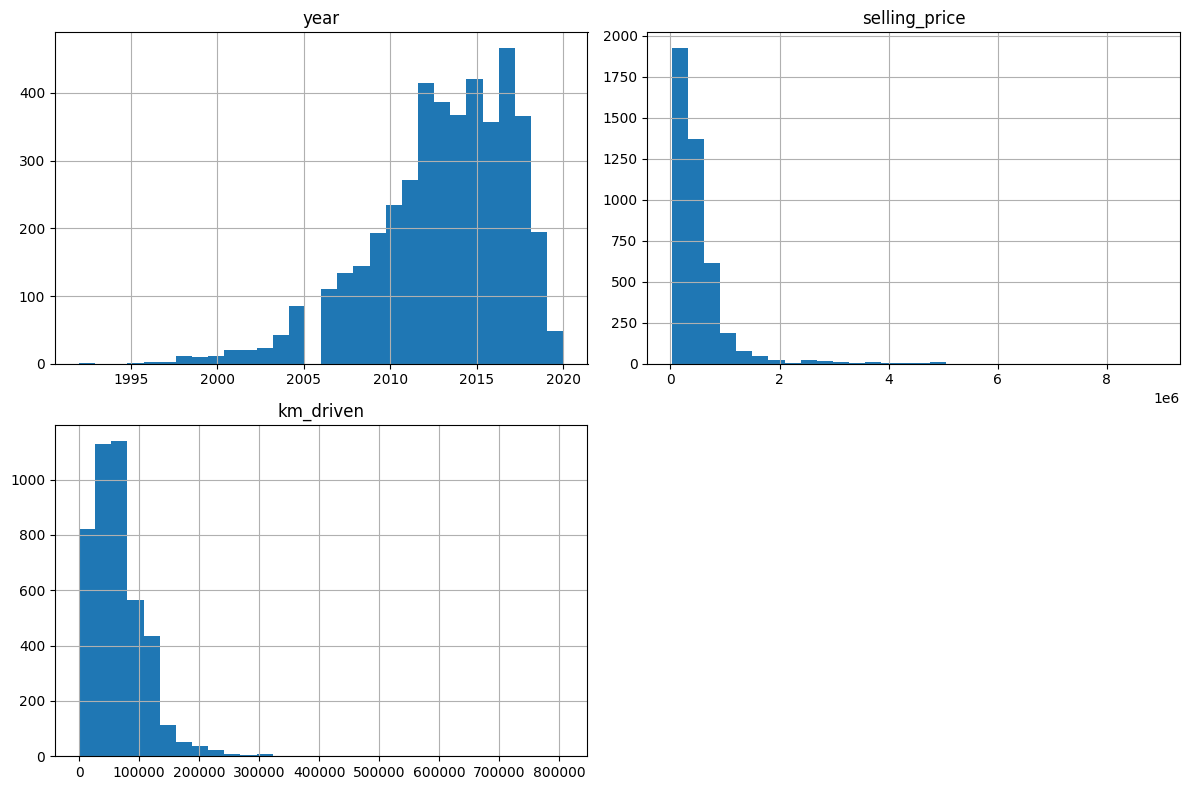

In [85]:
# Numerical distributions
df[numeric_features].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [86]:
# Skewness and Kurtosis
pd.DataFrame({
    "Skewness": df[numeric_features].skew(),
    "Kurtosis": df[numeric_features].kurt()
})

,Skewness,Kurtosis
year,-0.833240,0.668263
selling_price,4.892021,37.087543
km_driven,2.669057,23.316809


In [ ]:
# Optional: Combined numeric summary
numeric_summary = df[numeric_features].describe(

    percentiles=[.01, .25, .50, .75, .99]

).T

numeric_summary["skewness"] = df[numeric_features].skew()
numeric_summary["kurtosis"] = df[numeric_features].kurt()
numeric_summary

,count,mean,std,min,1%,25%,50%,75%,99%,max,skewness,kurtosis
year,4340.0,2013.090783,4.215344,1992.0,2001.00,2011.00,2014.0,2016.0,2020.0,2020.0,-0.833240,0.668263
selling_price,4340.0,504127.311751,578548.736139,20000.0,55000.00,208749.75,350000.0,600000.0,3200000.0,8900000.0,4.892021,37.087543
km_driven,4340.0,66215.777419,46644.102194,1.0,1444.68,35000.00,60000.0,90000.0,220000.0,806599.0,2.669057,23.316809


## 2.2 Catagorical Summary

Purpose: Assessing the composition, diversity and frequency distribution of categorical variables to identify dominant categories, rare categories, class imbalance and potentially problematic high-cardinality features. What categories exist in each variable, and how is the data distributed across them? What categories exist and how frequently do they occur?

* Number of unique values - Cardinality
* Category names - What groups actually exist
* Counts - How common each category is
* Percentages - Relative distribution
* Rare categories - Potential modelling issue
* Dominant categories - Potential imbalance
* Unexpected categories - Possible data-quality issue

In [131]:
# Categorical Summary ovierview
categorical_summary = pd.DataFrame({

    "Count": df[categorical_features].count(),
    "Unique": df[categorical_features].nunique(),
    "Missing": df[categorical_features].isnull().sum(),
    "Missing %": df[categorical_features].isnull().mean() * 100,
    "Most Frequent": [
        df[col].mode().iloc[0] if not df[col].mode().empty else None
        for col in categorical_features
    ]

})

categorical_summary

,Count,Unique,Missing,Missing %,Most Frequent
name,4340,1491,0,0.0,Maruti Swift Dzire VDI
fuel,4340,5,0,0.0,Diesel
seller_type,4340,3,0,0.0,Individual
transmission,4340,2,0,0.0,Manual
owner,4340,5,0,0.0,First Owner


In [129]:
for col in categorical_features:
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    display(summary.round(2))

,Count,Percentage
name,,
Maruti Swift Dzire VDI,69,1.59
Maruti Alto 800 LXI,59,1.36
Maruti Alto LXi,47,1.08
Maruti Alto LX,35,0.81
Hyundai EON Era Plus,35,0.81
...,...,...
Hyundai Verna Transform CRDi VGT SX ABS,1,0.02
Maruti S-Presso VXI Plus,1,0.02
Toyota Etios Liva 1.2 VX,1,0.02


,Count,Percentage
fuel,,
Diesel,2153,49.61
Petrol,2123,48.92
CNG,40,0.92
LPG,23,0.53
Electric,1,0.02


,Count,Percentage
seller_type,,
Individual,3244,74.75
Dealer,994,22.90
Trustmark Dealer,102,2.35


,Count,Percentage
transmission,,
Manual,3892,89.68
Automatic,448,10.32


,Count,Percentage
owner,,
First Owner,2832,65.25
Second Owner,1106,25.48
Third Owner,304,7.00
Fourth & Above Owner,81,1.87
Test Drive Car,17,0.39


* Name has 1491 unique names, so no distribution graph

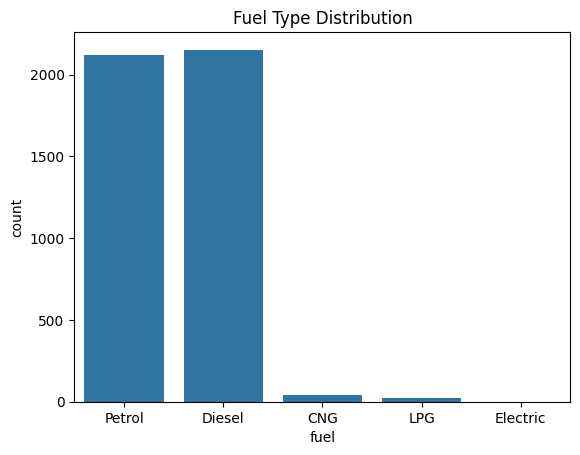

In [121]:
#Visualise Fuel
sns.countplot(data=df, x="fuel")
plt.title("Fuel Type Distribution")
plt.show()

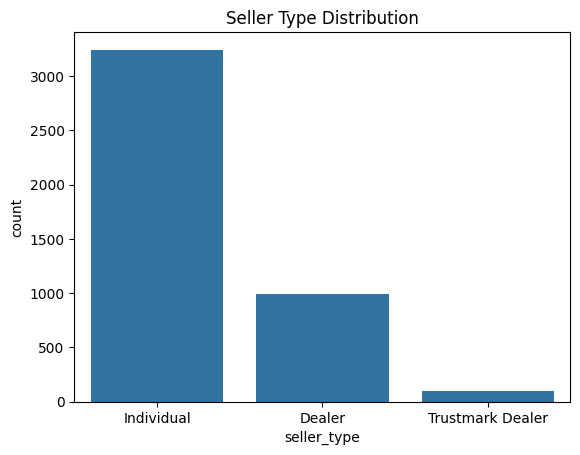

In [122]:
#Visualise Seller type
sns.countplot(data=df, x='seller_type')
plt.title("Seller Type Distribution")
plt.show()

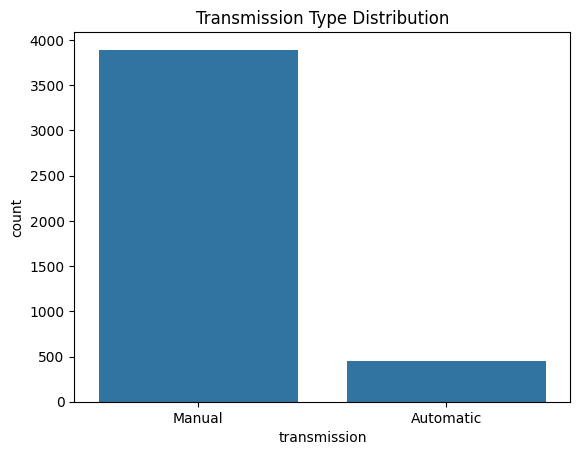

In [123]:
#Visualise Transmission
sns.countplot(data=df, x='transmission')
plt.title("Transmission Type Distribution")
plt.show()

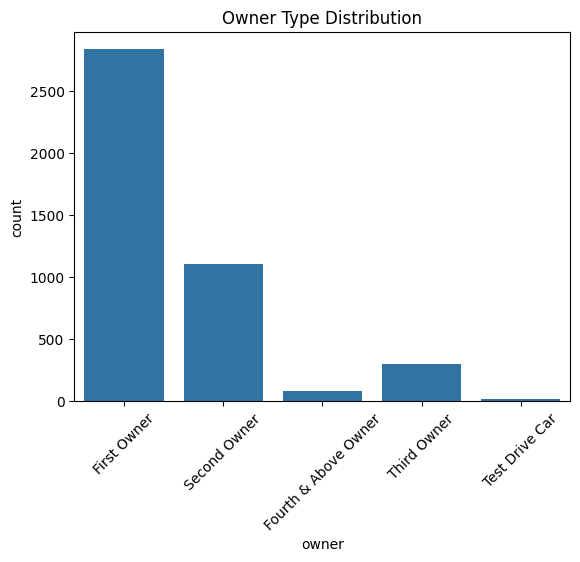

In [132]:
#Visualise Owner
sns.countplot(data=df, x='owner')
plt.xticks(rotation=45)
plt.title("Owner Type Distribution")
plt.show()

## 3. Data Quality Assessment
Purpose: Assessing the completeness, consistency and plausibility of the data by identifying missing values, duplicates, suspicious values and potential outliers that may require further investigation before modelling.

* Missing values
* Duplicates
* Invalid / suspicious values
* Potential outliers
* Extreme values

In [112]:
# High level overview (can replace below)
overview = pd.DataFrame({

    "Data Type": df.dtypes,
    "Non-Null": df.notnull().sum(),
    "Missing": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100,
    "Unique": df.nunique()
})

overview

,Data Type,Non-Null,Missing,Missing %,Unique
name,object,4340,0,0.0,1491
year,int64,4340,0,0.0,27
selling_price,int64,4340,0,0.0,445
km_driven,int64,4340,0,0.0,770
fuel,object,4340,0,0.0,5
seller_type,object,4340,0,0.0,3
transmission,object,4340,0,0.0,2
owner,object,4340,0,0.0,5


In [ ]:
# Missigness
missing = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percent': df.isnull().mean() * 100
})

missing[missing['Missing'] >= 0].sort_values(
    'Percent',
    ascending=False
)

,Missing,Percent
name,0,0.0
year,0,0.0
selling_price,0,0.0
km_driven,0,0.0
fuel,0,0.0
seller_type,0,0.0
transmission,0,0.0
owner,0,0.0


Note: If relevant for visualisation option: msno.matrix(df) , plt.show()

In [46]:
# Duplicates
df.duplicated().sum()

np.int64(763)

In [42]:
#Inspecting duplicated
df[df.duplicated(keep=False)].sort_values(

    by=list(df.columns)

)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3912,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
4016,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
99,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
2578,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
554,Audi A4 3.0 TDI Quattro,2013,1580000,86000,Diesel,Dealer,Automatic,First Owner
...,...,...,...,...,...,...,...,...
2936,Volkswagen Vento 1.5 TDI Highline Plus AT,2017,890000,40219,Diesel,Dealer,Automatic,First Owner
1628,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
3052,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
478,Volkswagen Vento Diesel Highline,2011,300000,65000,Diesel,Individual,Manual,Second Owner


* Observation: Various Car names have identical fuels, year, seller type, transmaission. Dupplication is not erreneours automatically.

In [95]:
# Suspicious numerical values/Impossible
df[numeric_features].describe(
    percentiles=[.01, .05, .25, .50, .75, .95, .99])

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
1%,2001.000000,5.500000e+04,1444.680000
5%,2005.000000,8.000000e+04,10000.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
95%,2019.000000,1.300000e+06,140000.000000


In [101]:
# Outliers / zooming into suspious values
df.nlargest(10, "km_driven")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
1243,Maruti Swift VXI BSIII,2009,250000,806599,Petrol,Dealer,Manual,First Owner
525,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,Dealer,Manual,First Owner
4184,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,Dealer,Manual,First Owner
3679,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2006,400000,400000,Diesel,Individual,Manual,Third Owner
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,Diesel,Individual,Manual,Second Owner
2394,Toyota Innova 2.5 V Diesel 8-seater,2009,350000,350000,Diesel,Individual,Manual,First Owner
3718,Toyota Innova 2.5 GX 8 STR BSIV,2009,420000,347089,Diesel,Dealer,Manual,First Owner
1674,Volkswagen Jetta 2.0 TDI Comfortline,2011,350000,312000,Diesel,Individual,Manual,Third Owner
1101,Tata Indica DLS,2006,85000,300000,Diesel,Individual,Manual,Second Owner
1659,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2006,229999,300000,Diesel,Individual,Manual,First Owner


In [102]:
# Outliers / zooming into suspious values
df.nlargest(10, "selling_price")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,Dealer,Automatic,First Owner
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017,8150000,6500,Diesel,Dealer,Automatic,First Owner
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,2016,5500000,77350,Diesel,Dealer,Automatic,First Owner
555,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
574,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
593,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
612,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
900,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
919,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
1023,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner


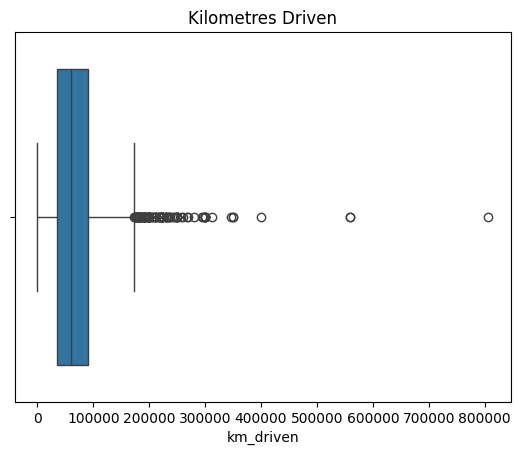

In [ ]:
# Visualise km-driven
sns.boxplot(x=df["km_driven"])
plt.title("Kilometres Driven")
plt.show()

<Axes: xlabel='km_driven', ylabel='Count'>

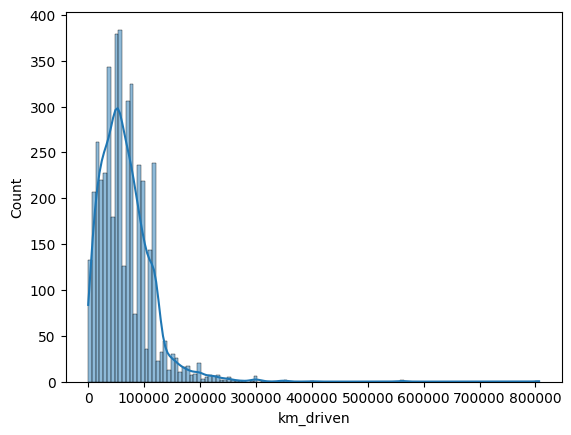

In [ ]:
# Visualise km-driven
sns.histplot(df["km_driven"], kde=True)

In [ ]:
df["km_driven"].describe(
    percentiles=[.01, .05, .25, .50, .75, .95, .99]
)

count      4340.000000
mean      66215.777419
std       46644.102194
min           1.000000
1%         1444.680000
5%        10000.000000
25%       35000.000000
50%       60000.000000
75%       90000.000000
95%      140000.000000
99%      220000.000000
max      806599.000000
Name: km_driven, dtype: float64

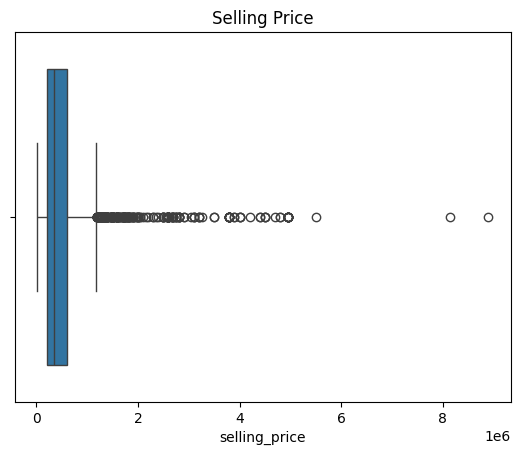

In [45]:
#Vuisualise selling price
sns.boxplot(x=df["selling_price"])
plt.title("Selling Price")
plt.show()

Observation: Extreme values observed  for both selling price and km-drive - to decide whether to remove or cap
year can be more meanigful if transfromed to age

## 4. Target variable Analysis (selling_price)

Purpose: Examine the distribution, central tendency, variability, skewness and potential extreme values of the target variable to understand its behaviour and identify transformations or other considerations that may affect modelling.

In [134]:
#zooming in into target variable selling_price
target = df["selling_price"]
target.describe()

count    4.340000e+03
mean     5.041273e+05
std      5.785487e+05
min      2.000000e+04
25%      2.087498e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64

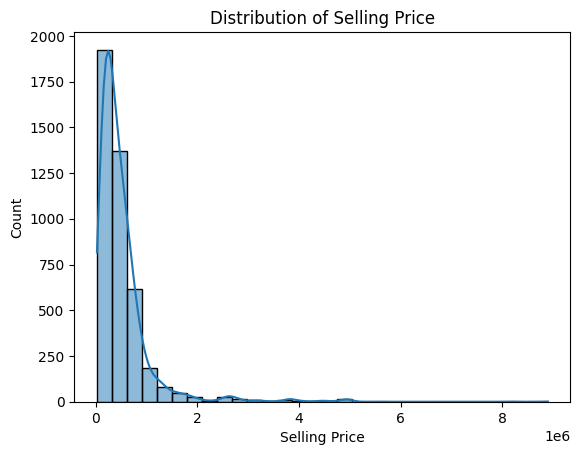

In [135]:
#Distribution of selling_price
sns.histplot(target, bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.show()

In [136]:
#Skewness and Kurtosis of selling_price
pd.DataFrame({
    "Skewness": [target.skew()],
    "Kurtosis": [target.kurt()]
})

,Skewness,Kurtosis
0,4.892021,37.087543


Observation: price is highly right-skewed, hence doesn't follow normal distribution, so before it has to be transformed, but checking forts if trabsafration wwould be useful.

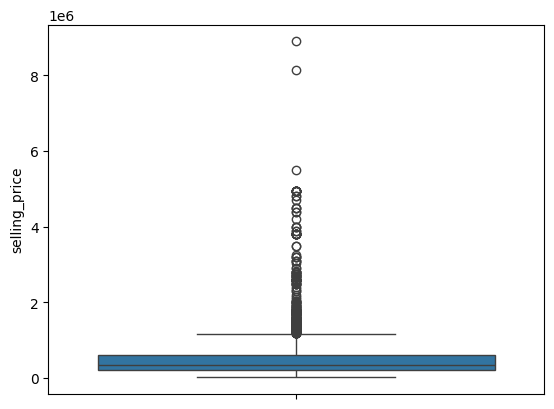

In [138]:
# Potential outliers
sns.boxplot(target)
plt.show()

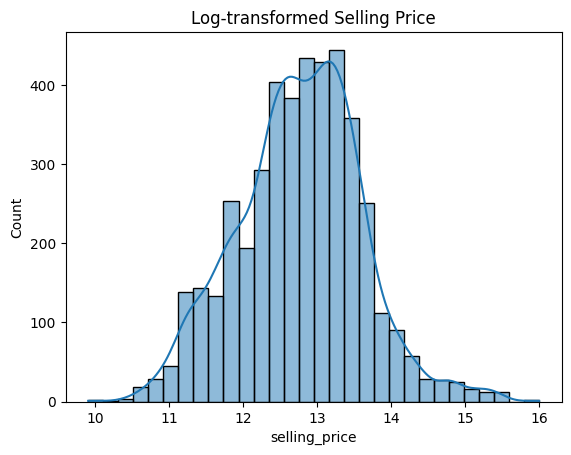

In [139]:
#Target transformation assessment - Investigating whether log transformation would be useful
import numpy as np

log_price = np.log1p(df["selling_price"])

sns.histplot(log_price, bins=30, kde=True)
plt.title("Log-transformed Selling Price")

plt.show()

In [94]:
#Skewness and Kurtosis of transformed selling_price
pd.DataFrame({
    "Skewness": [log_price.skew()],
    "Kurtosis": [log_price.kurt()]
})

,Skewness,Kurtosis
0,0.060173,0.2692


Observation: Log transformation substantially reduces positive skewness and should be considered during model preparation.

# 5. Relationships

## 5.1. Numerical relationships (Numerical ↔ target)

Purpose: Assess the direction, strength and form of relationships between numerical variables and the target, while identifying relationships between predictors that may be relevant for modelling.
What is associalted with the price? 

* Correlation coefficients
* Correlation heatmap
* Numerical X ↔ target scatterplots
* Regression plots
* Predictor ↔ predictor relationships
* Potential multicollinearity signals
* Non-linear patterns


Purpose:

Assess direction, strength and form of relationships

between numerical predictors and the target.

1. Correlation matrix
2. Target correlation table
3. Heatmap (optional for small datasets)
4. Scatter/regression plots for relevant predictors
5. Interpret patterns and unusual observations
6. Record findings in Feature Assessment

In [92]:
# Correlation analysis (How do variables relate to each other and the target) 
correlation = df[numeric_features].corr()
correlation

,year,selling_price,km_driven
year,1.000000,0.413922,-0.419688
selling_price,0.413922,1.000000,-0.192289
km_driven,-0.419688,-0.192289,1.000000


In [ ]:
# Closer corellation inspection
correlation["selling_price"].sort_values(
    ascending=False
)

selling_price    1.000000
year             0.413922
km_driven       -0.192289
Name: selling_price, dtype: float64

In [150]:
# Optional view: Closer correlation inspection]
price_corr = (
    df[numeric_features]
    .corr()["selling_price"]
    .drop("selling_price")
    .sort_values(ascending=False)
    .to_frame("Correlation")
)

price_corr.style.format("{:.3f}")

,Correlation
year,0.414
km_driven,-0.192


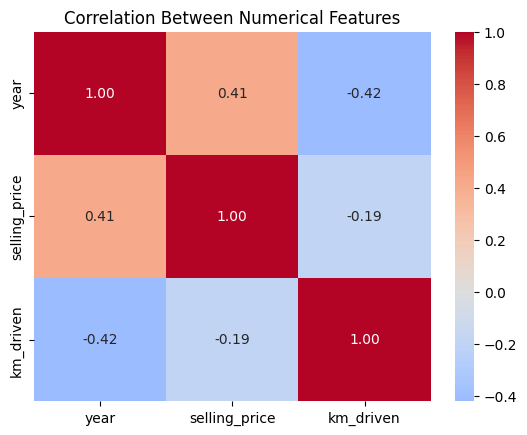

In [152]:
#Visualise correlation - Correlaction Heatmap
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Features")
plt.show()

Note: Combine domain logic + EDA findings + target relevance to define meaningful relationships
year, km_driven --> selling_price

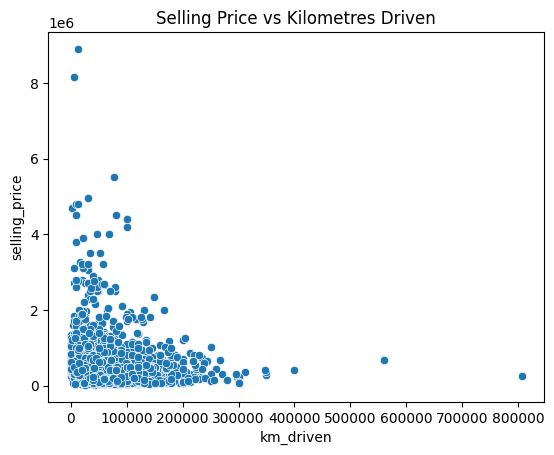

In [157]:
#Visualise Selling Price vs Kilometres Driven (not needed if below is available)
sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)
plt.title("Selling Price vs Kilometres Driven")
plt.show()

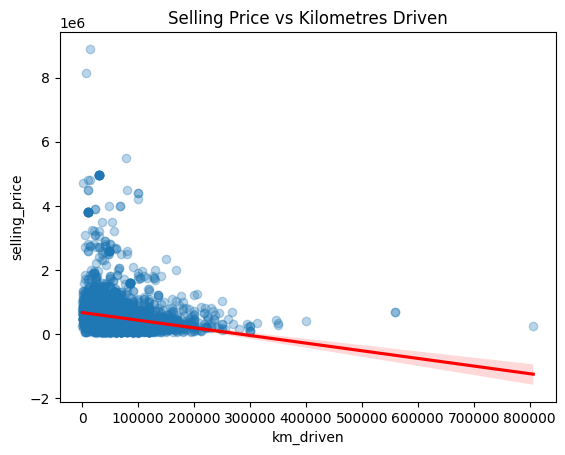

In [ ]:
#Visualise Selling Price vs Kilometres Driven incl regression line (exploration)

sns.regplot(
    data=df,
    x="km_driven",
    y="selling_price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Selling Price vs Kilometres Driven")

plt.show()

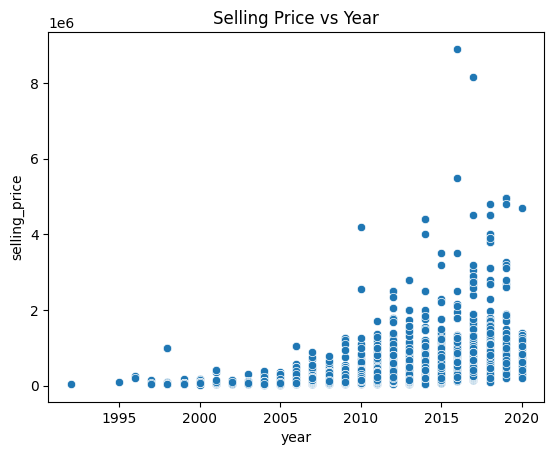

In [ ]:
#Visualise Selling Price vs Year (not needed if below is available)
sns.scatterplot(
    data=df,
    x="year",
    y="selling_price"
)
plt.title('Selling Price vs Year')
plt.show()

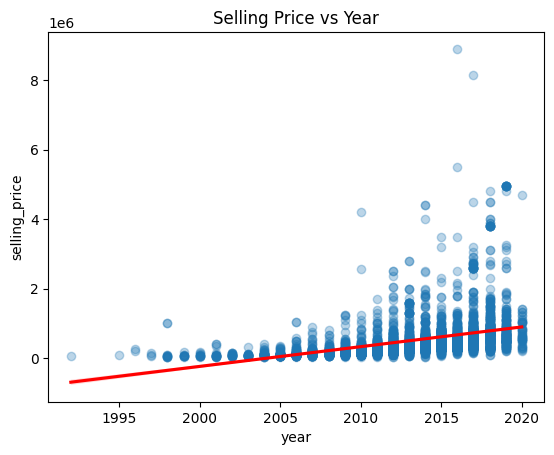

In [ ]:
#Visualise Selling Price vs Year incl regression line (exploration)
sns.regplot(

    data=df,
    x="year",
    y="selling_price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Selling Price vs Year")

plt.show()

Observation:
* r = -0.192 - weak negative association between km driven and selling price. Scatterplot shows that mosts cars are concentrated at lower mileage and lower-to-middle prices, there is substantial variation in price for similar mileage, and there are some very extreme mileage/price observations.
Higher milage cars tend to sell for less
* r = 0.414 = moderate positive association  between year and selling price. Newer vehicles tend to have higher selling prices. Scatter plots show that cars between 2013 - 2020 might have vary different prices. Year cointain important info but does not clearly explain the selling price.

* Also comong backt to: Year ↔ km driven = −0.420, newer cars tedn to have less km-driven
* There are also some high values high-price obervations among new vehicles

## 5.2. Categorical relationships - (Categorical ↔ target)

Purpose: Assessing whether the target variable differs across categories and identify categorical features that may provide useful information for prediction. Does price differes across groups?

* Boxplots
* Violin plots (when useful)
* Group means / medians
* Differences between categories
* Rare groups

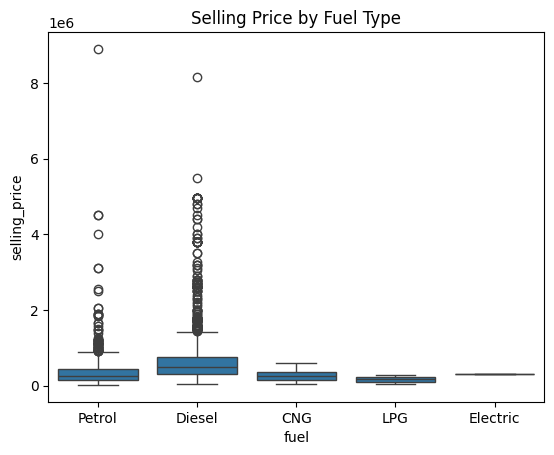

In [ ]:
#Visualise Selling Price vs Fuel
sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.show()

Shows that extreme prices exist and which fuel categories contain them.

In [144]:
#Checking at which point to limit the price
df["selling_price"].quantile([0.90, 0.95, 0.99])

0.90     900000.0
0.95    1300000.0
0.99    3200000.0
Name: selling_price, dtype: float64

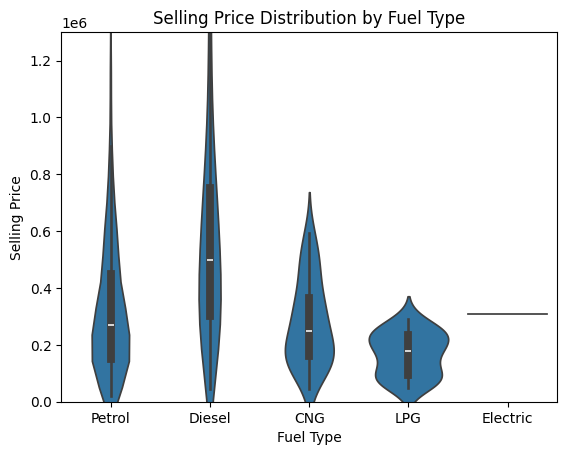

In [145]:
sns.violinplot(
    data=df,
    x="fuel",
    y="selling_price"
)
plt.ylim(0, 1300000)
plt.title("Selling Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

Zoom in :  the distribution of the majority of cars.
The full distribution contains a small number of high-price observations that compress the visualization. A zoomed view was therefore used to examine differences between fuel categories across the main price distribution.
* Diesel has the widest price spread and appears to have a higher typical selling price than most other fuel types. Its distribution also extends strongly into higher prices.
* Petrol is concentrated more heavily at lower prices, although there is a long upper tail.
* CNG appears concentrated at relatively lower-to-middle prices, again with a right tail.
* LPG shows an interesting shape: there appear to be different concentrations of cars around different price levels. This is something a violin plot makes easier to see than a standard boxplot.
* Electric should not be interpreted from this violin. The single horizontal-looking mark strongly suggests there may be only one or very few electric observations.

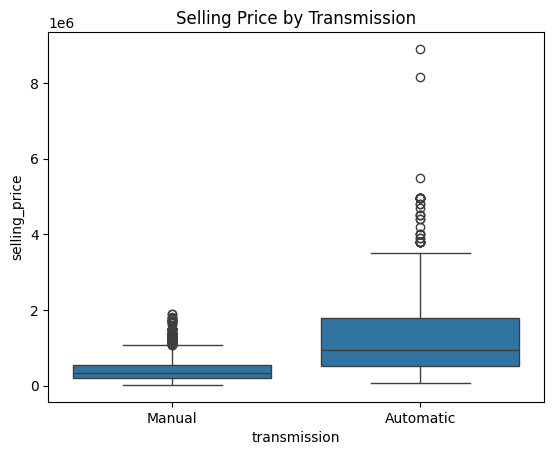

In [168]:
#Visualise Selling Price by Transmission
sns.boxplot(
    data=df,
    x="transmission",
    y="selling_price"
)
plt.title("Selling Price by Transmission")
plt.show()

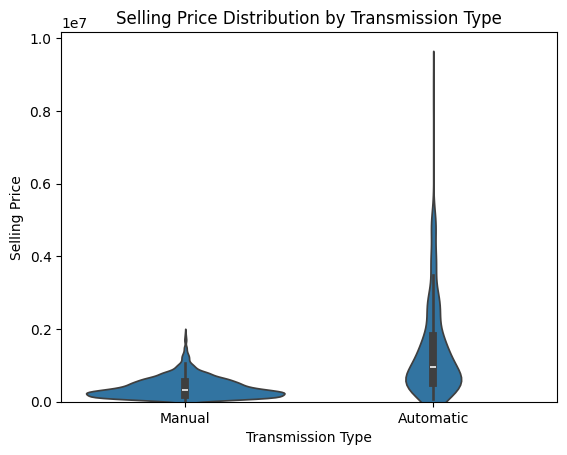

In [170]:
sns.violinplot(
    data=df,
    x="transmission",
    y="selling_price"
)
plt.ylim(0, )
plt.title("Selling Price Distribution by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Selling Price")
plt.show()

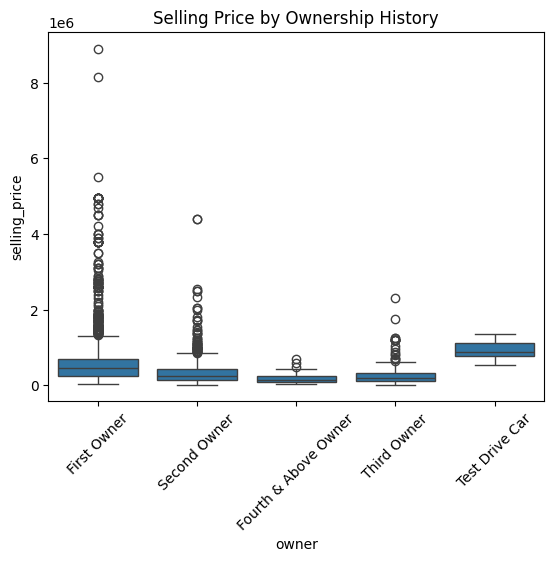

In [73]:
#Visualise Selling Price by Ownership
sns.boxplot(
    data=df,
    x="owner",
    y="selling_price"
)

plt.xticks(rotation=45)
plt.title("Selling Price by Ownership History")
plt.show()

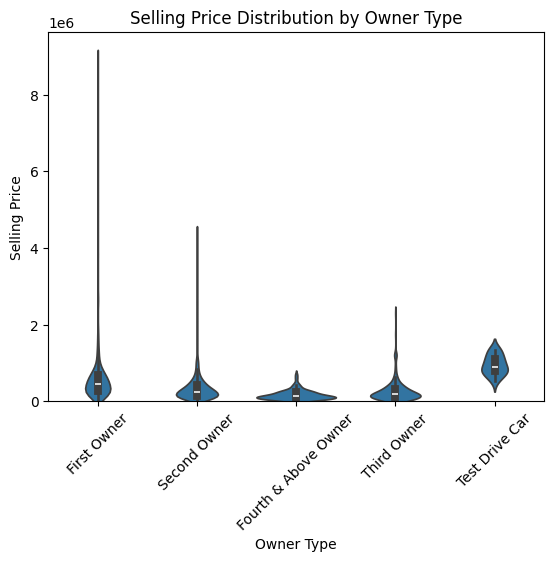

In [172]:
sns.violinplot(
    data=df,
    x="owner",
    y="selling_price"
)
plt.ylim(0, )
plt.xticks(rotation=45)
plt.title("Selling Price Distribution by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Selling Price")
plt.show()

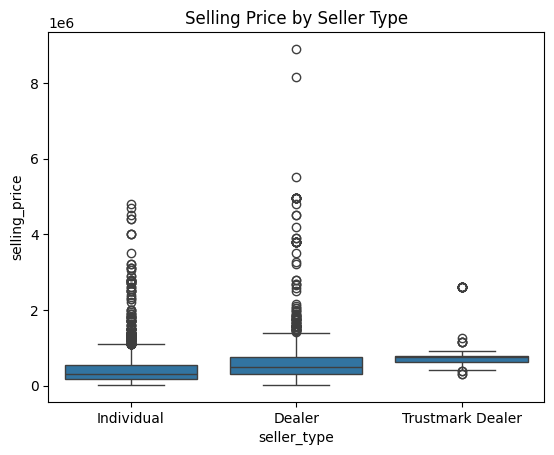

In [175]:
#Visualise Selling Price by Sellter_type
sns.boxplot(
    data=df,
    x="seller_type",
    y="selling_price"
)

plt.title("Selling Price by Seller Type")
plt.show()

Violin → distribution shape/density
Boxplot → median, IQR, spread and potential outliers.

So typical selling price increases across these groups.
    Middle line inside the box = median
    * Individual ≈ 300,000
    * Dealer ≈ 495,000
    * Trustmark Dealer ≈ 750,000

2. Box = middle 50% of observations (IQR)
    The bottom of the box is the 25th percentile (Q1) and the top is the 75th percentile (Q3).
    Dealer has a wider box than Individual → the middle 50% of Dealer prices are more dispersed.
3. Whiskers = typical range beyond the box
    They extend beyond the IQR according to the boxplot’s rule, usually up to 1.5 × IQR.
4. Individual dots beyond the whiskers = potential outliers
    This is where you can more confidently say potential outliers.

For your plot specifically, Individual and Dealer both contain many potential high-price outliers, but Dealer has considerably more extreme high-price observations—the highest are around 8–9 million.

Trustmark Dealer is interesting: its central distribution is relatively compact around the higher price range, but there are a few observations substantially above and below it.

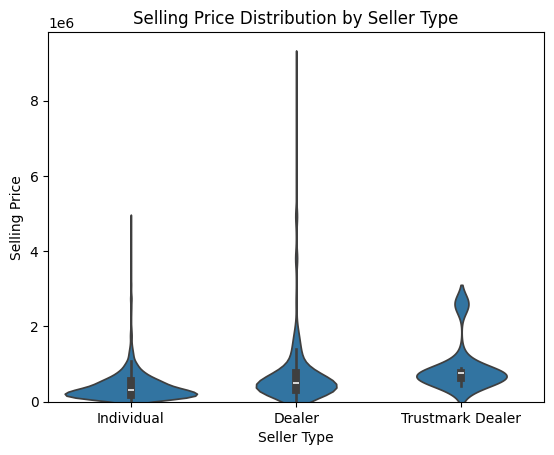

In [176]:
sns.violinplot(
    data=df,
    x="seller_type",
    y="selling_price"
)
plt.ylim(0, )
plt.title("Selling Price Distribution by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.show()

Dealer: Most Dealer cars are concentrated in the lower selling-price region, as shown by the wide bottom portion. The distribution becomes progressively narrower at higher prices, indicating fewer expensive cars, while the long thin upper tail indicates a small number of very high-priced cars.
Prices are distributed across a broader range, with greater concentration at medium/higher prices and a much longer upper tail containing very high-priced vehicles.

Indovidual: Selling prices are strongly concentrated in the lower price range. There are progressively fewer cars as price increases, producing a long but relatively thin upper tail. The distribution does contain high-priced vehicles, but the upper tail is less extreme than for Dealer vehicles.

- Violin outside = shape of distribution (its density not number of cars)
- Box inside = middle of distribution
- White dot = median
- Lonng line = outlirs, extreme values
- wide → higher density/concentration
- narrow → lower density/concentration
- long tail → observations exist there, but are relatively uncommon

* Wide part → many observations concentrated around those values
* Narrow part → relatively few observations
* Long thin tail → sparse observations extending toward extreme values
* Outliers → better identified with your boxplot, where individual points beyond the whiskers are shown as potential outliers

Does the distribution of my numerical target differ between categories?

In [178]:
#Does the distribution of my selling price differ between transmission categories?
df.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
transmission,,,
Automatic,448,1.408154e+06,950000.0
Manual,3892,4.000667e+05,325000.0


In [76]:
df.groupby("owner")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
owner,,,
First Owner,2832,598636.969633,450000.0
Fourth & Above Owner,81,173901.197531,130000.0
Second Owner,1106,343891.088608,250499.5
Test Drive Car,17,954293.941176,894999.0
Third Owner,304,269474.003289,190000.0


In [77]:
df.groupby("fuel")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
fuel,,,
CNG,40,277174.925000,247500.0
Diesel,2153,669094.252206,500000.0
Electric,1,310000.000000,310000.0
LPG,23,167826.043478,180000.0
Petrol,2123,344840.137541,269000.0


In [173]:
df.groupby("seller_type")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
seller_type,,,
Dealer,994,721822.890342,495000.0
Individual,3244,424505.419236,300000.0
Trustmark Dealer,102,914950.980392,750000.0


**Fuel <-> selling price**

1. Fuel categories are highly imbalanced. Petrol (n=2,123) and Diesel (n=2,153) dominate the dataset, while CNG (n=40) and LPG (n=23) are small groups. Electric has only one observation, no meaningful inference of an Electric price distribution.

2. Diesel cars have higher selling prices in this dataset. Diesel has both a higher mean (669,094) and median (500,000) than Petrol (mean 344,840; median 269,000). The violin plot also shows the Diesel distribution shifted toward higher prices.

3. Petrol and Diesel are strongly right-skewed. This is particularly clear from the boxplot: both contain numerous high-price observations. The means being substantially above the medians supports the same interpretation:

4. CNG and LPG have lower typical prices. CNG has a median of 247,500, while LPG has the lowest median at 180,000. However, their sample sizes are much smaller, so comparisons with Petrol/Diesel should be made cautiously.

5. Electric shouldn’t drive any modelling conclusion yet. n=1 explains the strange appearance in both your boxplot and violin plot. There simply isn’t a distribution to visualize.

**Summary Fuel**: Selling price varies across fuel types, with Diesel showing the highest median price and LPG the lowest. Petrol and Diesel exhibit strong upper-price tails and numerous potential outliers. Category representation is highly imbalanced, particularly for Electric (n=1), LPG (n=23) and CNG (n=40). --> Fuel shows potential predictive relevance, but rare categories require consideration during preprocessing and model evaluation.

**Transmission <-> selling price**

* Median price of an automatgoc is 2.9× the median manual price
* Violin plot shows that automatic cars have a more broader price distribution, extending considerbly into high price values. Manual cars are more concentrated in the lower price range
* The boxplot cofirms this and shows numereous high price potential outliers among automatic vehicles
* substantial category imbalance beetween manua; 90% anbd automatic 10% --> careful. Automatic vehicles in this dataset tend to have substantially higher selling prices than manual vehicles.
Q:? Automatic cars may also systematically be newer, more expensive makes/models, larger engines, etc.

Automatic vehicles show substantially higher median selling prices (950,000 vs 325,000) and greater price dispersion; categories are imbalanced (~90% manual)

**Owner <-> selling price**
* First → Second → Third → Fourth & Above, median selling price progressively decreases as the number of previous owners increases. The boxplot and violin plot both support that pattern.
* Test cars are different better than First Owner. It’s really a different type of ownership status, and there are only 17 observations. Its median price is approximately 895,000, substantially higher than the conventional owner categories. This could make sense because test-drive vehicles may be newer or have different characteristics—but your current analysis doesn’t establish why.
* There is also strong imbalance in categories --> decision for preproicessing
* mean > median for first and secodn owner. This reinforces the overall selling_price distribution being positively skewed.

Median price generally declines from First to Fourth & Above Owner; categories are imbalanced. Test Drive Car is rare (n=17), conceptually distinct and has a much higher median price

**Seller type <-> Selling price**
* Vehicles sold by dealers tend to have higher selling prices than those sold by individuals, while Trustmark Dealers show the highest median selling price. Confirmed by boxplot, the median shifts upward from Individual → Dealer → Trustmark Dealer.
* Violinplot : Individual vehicles are heavily concentrated in the lower price range. Dealer vehicles have a wider distribution and a much longer upper tail. Trustmark Dealer vehicles are concentrated at a higher price level, with what looks like a second small concentration around ~2.5 million.
* There’s substantial imbalance in catagories
* Positive skew within all groups, particularly Dealer (mean > median). Those very expensive dealer cars visible in the boxplot are pulling the mean upward.

Median selling price differs across seller types: Individual 300k, Dealer 495k, Trustmark Dealer 750k. Distributions are positively skewed and category sizes are imbalanced

## 6. Mulitvariate exploration (optional)

Purpose: Explore whether relationships identified in bivariate analysis change when additional variables are considered, and identify potential interactions or combined patterns relevant to modelling.

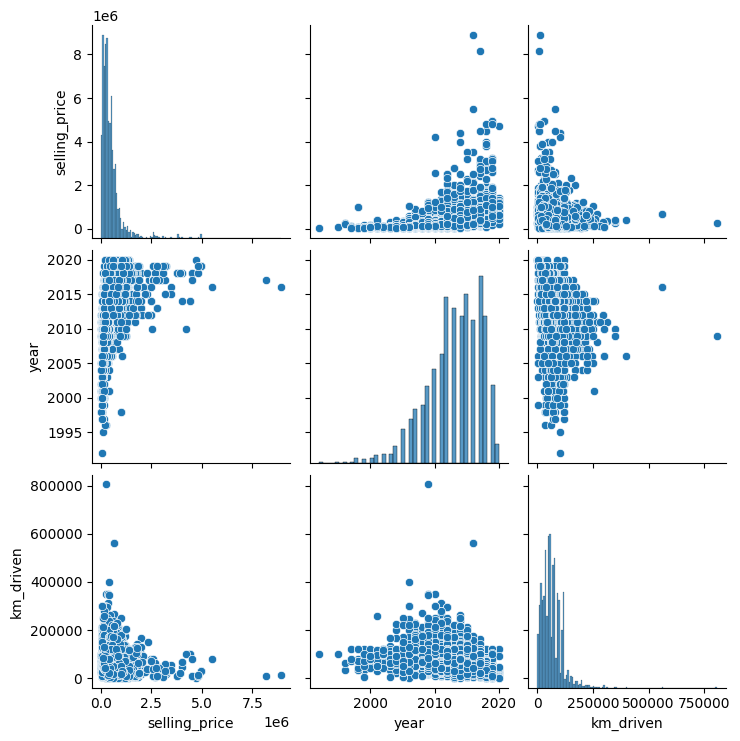

In [ ]:
# pair plot (small number of numerical features)
sns.pairplot(
    df[
        ["selling_price", "year", "km_driven"]
    ]
)
plt.show()

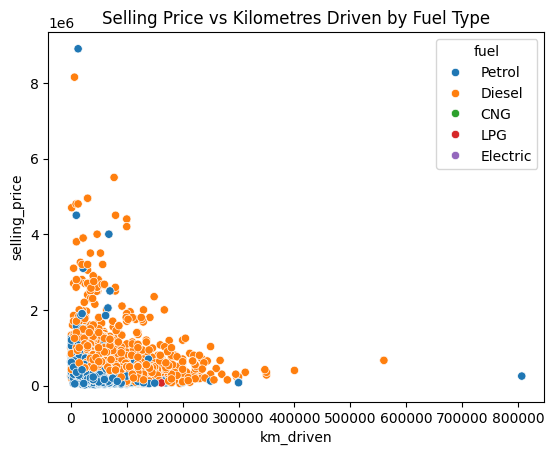

In [159]:
sns.scatterplot(

    data=df,

    x="km_driven",

    y="selling_price",

    hue="fuel"

)

plt.title("Selling Price vs Kilometres Driven by Fuel Type")

plt.show()

In [ ]:
#determine limitis from procentiles
df[["km_driven", "selling_price"]].quantile([0.95, 0.99])

,km_driven,selling_price
0.95,140000.0,1300000.0
0.99,220000.0,3200000.0


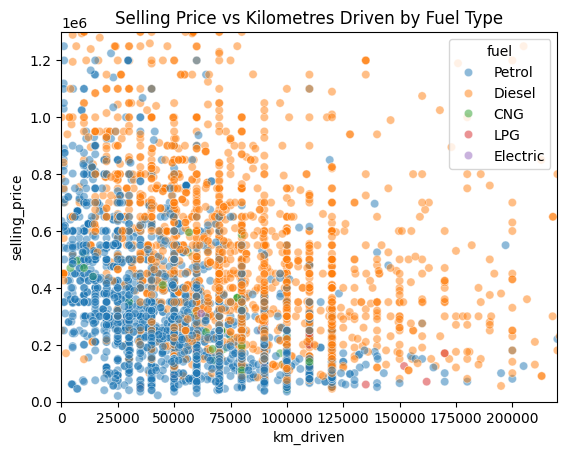

In [162]:
sns.scatterplot(

    data=df,
    x="km_driven",
    y="selling_price",
    hue="fuel",
    alpha=0.5

)

plt.xlim(0, 220000)
plt.ylim(0, 1300000)
plt.title("Selling Price vs Kilometres Driven by Fuel Type")

plt.show()

No clear additional multivariate pattern was identified visually due to substantial overlap between fuel categories.

## 7. Feature assessment — What might enter the model?
→ Keep / transform / derive / investigate / exclude


EDA Conclusion --> 8. Train/Test Split --> Preprocess

In [177]:
feature_decisions = pd.DataFrame({
    "Feature": [
        "name",
        "year",
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner"
    ],
    "Type": [
        "Categorical",
        "Numerical",
        "Numerical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical"
    ],
    "EDA Finding": [
        "Many unique vehicle names/models",
        "moderate positive association with price (r = 0.414); substantial price variation within 2013-2020 years",
        "Weak negative relationship with price (r ≈ −0.192); right-skewed with extreme mileage",
        "Price distributions differ; Diesel has higher median; strong category imbalance",
        "Median selling price differs across seller types: Individual 300k, Dealer 495k, Trustmark Dealer 750k. Distributions are positively skewed and category sizes are imbalanced",
        "Automatic vehicles show substantially higher median selling prices (950,000 vs 325,000) and greater price dispersion; categories are imbalanced (~90% manual)",
        "Median price generally declines from First to Fourth & Above Owner; categories are imbalanced. Test Drive Car is rare (n=17), conceptually distinct and has a much higher median price"
    ],
    "Decision": [
        "Investigate",
        "Keep/consider deriving age",
        "Keep/Investigate",
        "Keep",
        "Keep",
        "Keep",
        "Keep / investigate rare category"
    ],
    "Rationale": [
        "Consider extracting make/model rather than directly encoding raw name",
        "show predictive relevance, age might be more interpretable",
        "Assess extreem values, transfromation to may be considered",
        "Encode; rare categories require consideration",
        "Clear target differentiation suggests potential predictive value; categorical encoding required",
        "Strong categorical differentiation in target suggests potential predictive value; requires encoding",
        "Clear differentiation in target suggests predictive relevance; categorical encoding required and Test Drive Car warrants separate consideration"
    ]
})

feature_decisions

,Feature,Type,EDA Finding,Decision,Rationale
0,name,Categorical,Many unique vehicle names/models,Investigate,Consider extracting make/model rather than dir...
1,year,Numerical,moderate positive association with price (r = ...,Keep/consider deriving age,"show predictive relevance, age might be more i..."
2,km_driven,Numerical,Weak negative relationship with price (r ≈ −0....,Keep/Investigate,"Assess extreem values, transfromation to may b..."
3,fuel,Categorical,Price distributions differ; Diesel has higher ...,Keep,Encode; rare categories require consideration
4,seller_type,Categorical,Median selling price differs across seller typ...,Keep,Clear target differentiation suggests potentia...
5,transmission,Categorical,Automatic vehicles show substantially higher m...,Keep,Strong categorical differentiation in target s...
6,owner,Categorical,Median price generally declines from First to ...,Keep / investigate rare category,Clear differentiation in target suggests predi...


**EDA SUMMARY:**
Selling price is strongly right-skewed and contains several extreme high-price observations. Numerical analysis indicates a moderate positive association between vehicle year and selling price, while kilometres driven shows a weaker negative association.

Categorical analysis indicates meaningful differences in selling-price distributions across fuel type, transmission, seller type and ownership status. Several categorical variables are imbalanced, with particularly rare categories requiring consideration.

Vehicle name has high cardinality and requires further feature-engineering consideration. Overall, both numerical and categorical variables show potential predictive relevance.

---

Example: 
* Target: selling_price is strongly right-skewed with extreme high values --> Investigate log transformation and influence of extremes
* Numerical predictors: Newer cars tend to have higher prices (r≈.41); mileage has a weaker negative association (r≈−.19) --> Retain both; consider deriving vehicle age
* Categorical predictors: Price distributions differ across fuel, transmission, owner and seller type --> Retain and encode categorical predictors
* Data structure: Several categorical groups are imbalanced/rare; name has high cardinality --> Investigate rare categories and engineer make/model from name

EDA identified both numerical and categorical signals relevant to vehicle selling price. Newer vehicles generally achieve higher prices, while higher mileage shows a weaker negative association with price. Selling-price distributions also differ across transmission, fuel, seller type and ownership categories.

The analysis additionally identified strong positive skew and extreme values in selling price, imbalanced and rare categorical groups, and high cardinality in vehicle name. These findings inform the subsequent preprocessing strategy, particularly feature engineering, categorical encoding and assessment of target transformation and extreme observations.

# EDA Complete

### Identified preprocessing considerations

- Derive vehicle age from `year`

- Investigate extreme `selling_price` and `km_driven` observations

- Assess potential target log transformation

- Encode categorical variables

- Assess treatment of rare categories

- Engineer useful information from `name`

No preprocessing transformations have yet been applied.

---

EDA complete → define X/y → train/test split → preprocessing → multiple regression.

# 8. Train/Test Split

Purpose: Separate the dataset into training and test sets so the model can be developed using the training data and later evaluated on previously unseen observations.

In [239]:
# Setting the target
y = df["selling_price"]

# Define predictors
X = df.drop(columns=["selling_price"])

In [240]:
X.head()

,name,year,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,141000,Diesel,Individual,Manual,Second Owner


In [241]:
y.head()

0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64

In [260]:
#Split train/test setup

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

* Original data set 100%
* 80% - TRAIN SET -  X_train | y_train --> Deployment + Learning
* 20% - TEST SET  - X_test | y_test --> Leaving untauched

In [261]:
# Verfiy the split
pd.DataFrame({
    "Dataset": ["Full", "Training", "Test"],
    "Observations": [
        len(df),
        len(X_train),
        len(X_test)
    ],

    "Percentage": [
        100,
        len(X_train) / len(df) * 100,
        len(X_test) / len(df) * 100
    ]

}).style.format({

    "Percentage": "{:.1f}%"

}).hide(axis="index")

Dataset,Observations,Percentage
Full,4340,100.0%
Training,3472,80.0%
Test,868,20.0%


SAVE CSV FILES

In [262]:
df.to_csv("car_original.csv",index=False)

In [191]:
train = X_train.copy()
train["selling_price"] = y_train

test = X_test.copy()
test["selling_price"] = y_test

In [192]:
train.to_csv("car_train.csv", index=False)

test.to_csv("car_test.csv", index=False)

In [193]:
#Verfiy
pd.DataFrame({

    "Dataset": ["Original", "Train", "Test"],

    "Rows": [

        len(df),

        len(train),

        len(test)

    ],

    "Columns": [

        df.shape[1],

        train.shape[1],

        test.shape[1]

    ]

})

,Dataset,Rows,Columns
0,Original,4340,8
1,Train,3472,8
2,Test,868,8


In [194]:
len(train) + len(test) == len(df)

True

**EXCEPTION**

In [263]:
# EXCEPTION: Wrong preprocessing step: 
import pandas as pd

train = pd.read_csv("car_train.csv")

test = pd.read_csv("car_test.csv")

In [264]:
# Separate train anmd set again

X_train = train.drop(columns=["selling_price"])

y_train = train["selling_price"]

X_test = test.drop(columns=["selling_price"])

y_test = test["selling_price"]

In [265]:
#Check
X_train.head()

X_train.shape, X_test.shape

((3472, 7), (868, 7))

# 9. Preprocessing

Purpose: Prepare predictors for modelling based on issues identified during EDA, while ensuring that information from the test set does not influence model development.

1. year → derive vehicle age
2. name → deal with high cardinality / extract useful car information
3. Categorical variables → encode them
4. Numerical variables → decide whether transformations/outlier treatment are actually needed

In [266]:
import pandas as pd

train = pd.read_csv("car_train.csv")

test = pd.read_csv("car_test.csv")

### 9.1 Feature engineering (Year → Age)

In [267]:
# checking the when selling_price was recorded when the dataset was collected.

df["year"].min(), df["year"].max()

(np.int64(1992), np.int64(2020))

Kaggale source reports 06/27/2020 is the dataset’s collection/reference date, then using 2020 as the reference year is reasonable for a year-level age feature.

In [268]:
df["year"].value_counts().sort_index().tail(10)

year
2011    271
2012    415
2013    386
2014    367
2015    421
2016    357
2017    466
2018    366
2019    195
2020     48
Name: count, dtype: int64

In [269]:
# Create vehicle age
X_train["age"] = 2020 - X_train["year"]
X_test["age"] = 2020 - X_test["year"]

In [270]:
#Check results
X_train[["year", "age"]].head()

,year,age
0,2017,3
1,2018,2
2,2013,7
3,2011,9
4,2017,3


In [271]:
# Remove year, as duplicated information
X_train = X_train.drop(columns=["year"])

X_test = X_test.drop(columns=["year"])

In [272]:
X_train.head()

,name,km_driven,fuel,seller_type,transmission,owner,age
0,Mahindra Scorpio S11 BSIV,20000,Diesel,Individual,Manual,First Owner,3
1,Maruti Swift Dzire VDI,50000,Diesel,Individual,Manual,First Owner,2
2,Maruti Alto 800 LXI,25000,Petrol,Individual,Manual,Second Owner,7
3,Chevrolet Beat Diesel LS,70000,Diesel,Individual,Manual,First Owner,9
4,Maruti Vitara Brezza LDi Option,72000,Diesel,Dealer,Manual,First Owner,3


### 9.2 Investigate name

In [274]:
# Inspection
X_train["name"].nunique()

1323

In [275]:
X_train["name"].value_counts().head(20)

name
Maruti Swift Dzire VDI           53
Maruti Alto 800 LXI              51
Maruti Alto LXi                  31
Maruti Alto LX                   29
Hyundai EON Era Plus             27
Maruti Wagon R VXI BS IV         26
Maruti Swift VDI BSIV            25
Maruti Swift VDI                 24
Maruti 800 AC                    21
Maruti Wagon R LXI               19
Maruti Alto K10 VXI              18
Hyundai i10 Magna                18
Hyundai EON Magna Plus           18
Hyundai Creta 1.6 CRDi SX        16
Chevrolet Beat Diesel LT         16
Renault KWID 1.0 RXT Optional    15
Hyundai Santro Xing GLS          15
Maruti Wagon R LXI Minor         15
Maruti SX4 Vxi BSIV              14
Renault KWID RXT                 14
Name: count, dtype: int64

In [276]:
X_train["name"].head(20)

0           Mahindra Scorpio S11 BSIV
1              Maruti Swift Dzire VDI
2                 Maruti Alto 800 LXI
3            Chevrolet Beat Diesel LS
4     Maruti Vitara Brezza LDi Option
5                Toyota Etios 1.4 VXD
6                    Datsun GO T BSIV
7                 Maruti Alto K10 LXI
8                Honda City i-VTEC ZX
9         Hyundai Xcent 1.1 CRDi Base
10             Maruti Swift Dzire VDI
11          Toyota Innova 2.5 E 8 STR
12                 Maruti Wagon R LXI
13           Maruti Wagon R VXI BS IV
14              Chevrolet Aveo 1.4 LS
15             Maruti Zen LX - BS III
16                     Maruti Alto LX
17         Maruti Alto K10 VXI Airbag
18             Maruti Swift Dzire VDi
19             Maruti Swift Vdi BSIII
Name: name, dtype: object

Maruti (Make)
Swift Dzire VDI ( Model/variant)

In [277]:
# Extract brand Name
X_train["brand"] = X_train["name"].str.split().str[0]
X_test["brand"] = X_test["name"].str.split().str[0]

In [278]:
X_train[["name", "brand"]].head(10)

,name,brand
0,Mahindra Scorpio S11 BSIV,Mahindra
1,Maruti Swift Dzire VDI,Maruti
2,Maruti Alto 800 LXI,Maruti
3,Chevrolet Beat Diesel LS,Chevrolet
4,Maruti Vitara Brezza LDi Option,Maruti
5,Toyota Etios 1.4 VXD,Toyota
6,Datsun GO T BSIV,Datsun
7,Maruti Alto K10 LXI,Maruti
8,Honda City i-VTEC ZX,Honda
9,Hyundai Xcent 1.1 CRDi Base,Hyundai


In [279]:
# Drop the original high coordinality name 
X_train = X_train.drop(columns=["name"])

X_test = X_test.drop(columns=["name"])

In [282]:
#  Verfiy
X_train.columns

Index(['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'age',
       'brand'],
      dtype='object')

In [280]:
X_train["brand"].value_counts()

brand
Maruti           1028
Hyundai           643
Tata              292
Mahindra          289
Honda             201
Ford              195
Toyota            162
Chevrolet         156
Renault           117
Volkswagen         87
Nissan             53
Skoda              52
Audi               48
Mercedes-Benz      31
Datsun             31
BMW                31
Fiat               25
Mitsubishi          6
Jaguar              5
Volvo               4
Ambassador          4
Land                3
Jeep                3
MG                  2
Isuzu               1
OpelCorsa           1
Kia                 1
Force               1
Name: count, dtype: int64

name: High-cardinality feature containing brand, model and variant information. Brand was extracted and the original name removed to reduce dimensionality. This simplifies the model but loses model/variant-level information.

Also, the transformation confirms that extracting brand has worked, but it also reveals the next preprocessing issue: rare categories. brand_Isuzu, Kia, Force

In [283]:
#Applying threshold to 25 for rare brands, only using training set

rare_brands = (
    X_train["brand"]
    .value_counts()
    .loc[lambda x: x < 25]
    .index
)

rare_brands

Index(['Mitsubishi', 'Jaguar', 'Volvo', 'Ambassador', 'Land', 'Jeep', 'MG',
       'Isuzu', 'OpelCorsa', 'Kia', 'Force'],
      dtype='object', name='brand')

We learn from training set and then  apply the rule to both. ie. Learn decisions "Volvo is rare", so lets aggregate. I have not seen the test set results so I am not biased. Otherwise this would be information leakage. 

**Key Preprocessing rule** Learn from train; apply to train and test. Never learn preprocessing rules from test.

In [284]:
# Apply the rule to training list  
X_train["brand"] = X_train["brand"].where(

    ~X_train["brand"].isin(rare_brands),

    "Other"

)

In [285]:
# Apply the rule to test list 
X_test["brand"] = X_test["brand"].where(

    ~X_test["brand"].isin(rare_brands),

    "Other"

)

In [286]:
#Verify
X_train["brand"].value_counts()

brand
Maruti           1028
Hyundai           643
Tata              292
Mahindra          289
Honda             201
Ford              195
Toyota            162
Chevrolet         156
Renault           117
Volkswagen         87
Nissan             53
Skoda              52
Audi               48
Other              31
Datsun             31
Mercedes-Benz      31
BMW                31
Fiat               25
Name: count, dtype: int64

11 Brands represented by fewer than 25 observations in the training set were grouped into an Other category to reduce sparsity before categorical encoding. The training set is where make/learn preprocessing decisions. The test set is supposed to simulate genuinely unseen future data.

In [289]:
#Check count per brand 
brand_counts = pd.DataFrame({

    "Count": X_train["brand"].value_counts(),
    "Percentage": X_train["brand"].value_counts(normalize=True) * 100
})

brand_counts.style.format({
    "Percentage": "{:.2f}%"

})

,Count,Percentage
brand,,
Maruti,1028,29.61%
Hyundai,643,18.52%
Tata,292,8.41%
Mahindra,289,8.32%
Honda,201,5.79%
Ford,195,5.62%
Toyota,162,4.67%
Chevrolet,156,4.49%
Renault,117,3.37%


In [290]:
# Final check before encoding
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   km_driven     3472 non-null   int64 
 1   fuel          3472 non-null   object
 2   seller_type   3472 non-null   object
 3   transmission  3472 non-null   object
 4   owner         3472 non-null   object
 5   age           3472 non-null   int64 
 6   brand         3472 non-null   object
dtypes: int64(2), object(5)
memory usage: 190.0+ KB


# 9.3 Categorical encoding
Purpose: Convert categorical predictors into numerical representations that can be used by multiple linear regression while preserving category membership. Linear Regression works only with numbers

Numerical predictors:
* age
* km-driven

Categorical: 
* brand
* fuel
* seller_type
* transmission
* owner

In [297]:
# 1. Define categorical features
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

categorical_features

Index(['fuel', 'seller_type', 'transmission', 'owner', 'brand'], dtype='object')

Applying one-hot encoding to to binary columns
Example; Manual = 0 vs Automatic = 1, Manual remains as a reference category
* drop="first" → drops one category from each feature to provide a reference category.
* handle_unknown="ignore" → if the test data contain a category the encoder didn’t see during training, it won’t crash.
* sparse_output=False → gives us a regular array, which is easier to inspect while learning.

In [298]:
# 2. Load and create Encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(

    drop="first",
    handle_unknown="ignore",
    sparse_output=False

)

In [299]:
# 3. Fit Encoder only on Training data
encoder.fit(X_train[categorical_features])

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


The encoder has now learned the categories from training data. Let's inspect.

In [294]:
# 4. Inspecting
encoder.categories_

[array(['CNG', 'Diesel', 'Electric', 'LPG', 'Petrol'], dtype=object),
 array(['Dealer', 'Individual', 'Trustmark Dealer'], dtype=object),
 array(['Automatic', 'Manual'], dtype=object),
 array(['First Owner', 'Fourth & Above Owner', 'Second Owner',
        'Test Drive Car', 'Third Owner'], dtype=object),
 array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Ford', 'Honda',
        'Hyundai', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Nissan',
        'Other', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen'],
       dtype=object)]

In [300]:
# 5. Transform train
X_train_encoded = encoder.transform(
    X_train[categorical_features]
)

Transforing test have 1 unpapped brand dewoo, available on Test not in Train set. Mapping the brand to rare brands

In [301]:
# 6. Map unseen TEST brands to "Other"
known_brands = set(X_train["brand"].unique())

X_test["brand"] = X_test["brand"].where(
    X_test["brand"].isin(known_brands),
    "Other"

)

In [ ]:
# Check if any discrepancies between sets
set(X_test["brand"].unique()) - set(X_train["brand"].unique())

set()

In [ ]:
# 7. Transform TEST

X_test_encoded = encoder.transform(
    X_test[categorical_features])

In [ ]:
# 8. Get encoded column names
encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

In [ ]:
# 9. Convert to DataFrames

X_train_cat = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index

)

X_test_cat = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index

)

Now I have 2 encoded predictors:
* X_train_cat  → encoded categorical predictors
* X_test_cat   → same encoded structure for test

Now proceeding with combining them with numerical features (age and km_driven)

In [ ]:
#Creating numerical parts
numeric_features = ["age", "km_driven"]

X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

In [310]:
#Combine numerical + encoded categorcial features
X_train_final = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
    )

X_test_final = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

In [311]:
#Verify
X_train_final.head()

,age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,...,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Nissan,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,3,20000,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,50000,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7,25000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9,70000,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,72000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [312]:
#Verfiy
X_train_final.shape, X_test_final.shape

((3472, 30), (868, 30))

In [313]:
#Verify extra
(X_train_final.columns == X_test_final.columns).all()

np.True_

In [314]:
#Check for numerical values only
X_train_final.dtypes.value_counts()

float64    28
int64       2
Name: count, dtype: int64

# Multiple Linear Regression model


In [ ]:
# Fitting Multiple Linear Regression model. Model learns from the training set only. 
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train_final, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Inspecting the intercept and coeffcients

In [ ]:
# Inspecting the intercept
mlr.intercept_

np.float64(2039522.6470487183)

In [325]:
# Inspecting the coeffcients
coefficients = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Coefficient": mlr.coef_
})

(
    coefficients
    .sort_values("Coefficient", ascending=False)
    .style
    .format({
        "Coefficient": "{:,.2f}"
    })
    .hide(axis="index")
)

Feature,Coefficient
brand_BMW,"1,105,457.44"
brand_Mercedes-Benz,"1,063,598.63"
seller_type_Trustmark Dealer,"249,421.26"
fuel_Diesel,"192,587.61"
owner_Test Drive Car,"137,426.33"
fuel_LPG,"60,135.21"
owner_Fourth & Above Owner,"12,547.31"
fuel_Petrol,"9,392.73"
km_driven,-0.95
brand_Other,"-13,912.91"


NOTE: Categorical coefficients are relative to the dropped reference category, and coefficients are expressed in the original units of each feature. 

### Prediction

In [321]:
### Predicting unseen test cars
y_pred = mlr.predict(X_test_final)

In [324]:
#Prediction results
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results["Error"] = results["Actual Price"] - results["Predicted Price"]
(

    results.head(10)
    .style
    .format({
        "Actual Price": "{:,.0f}",
        "Predicted Price": "{:,.0f}",
        "Error": "{:,.0f}"
    })
    .hide(axis="index")
)

Actual Price,Predicted Price,Error
"165,000","255,035","-90,035"
"250,000","481,510","-231,510"
"120,000","99,426","20,574"
"450,000","486,056","-36,056"
"730,000","1,018,937","-288,937"
"155,000","254,625","-99,625"
"530,000","510,780","19,220"
"92,800","288,147","-195,347"
"284,000","574,550","-290,550"
"260,000","366,779","-106,779"


Note: error is negative - overpredicted, positive - underpredicted

### Model evaluation

In [ ]:
# Calculate main regression metrics - MAE, RMSE, R²

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [327]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]})

(
    metrics.style
    .format({"Value": lambda x: f"{x:,.3f}" if abs(x) < 10 else f"{x:,.0f}"})
    .hide(axis="index")
)

Metric,Value
MAE,"188,667"
RMSE,"384,020"
R²,0.517


* MAE - On average, how far is my predicted selling price from the actual selling price?
* RMSE - Measures prediction error, but penalizes large mistakes more heavily.
* R² - How much of the variation in selling prices does my model explain?

Interpretation: 
* MAE	188,667 - prediciton is off by about 189K price unit on average
* RMSE	384,020 - this gap suggest that some cars have large prediction errors, substantial effect
    RMSE is more than 2x MAE, Because RMSE penalizes large errors more strongly, this suggests that some cars are being predicted very poorly, while the typical error is considerably smaller.

* R²	0.517 - ~52% of variation in unseen selling price is explained by the model

The baseline multiple linear regression explains approximately 51.7% of the variance in unseen selling prices, while the substantial difference between MAE and RMSE indicates the presence of relatively large prediction errors.

This aligns with EDA - skewness, extreme prices and potentially non-linear relationships — are actually affecting the regression.

### Residual analysis 
where is model going wrong? 

**Residual = Actual − Predicted**

* (+) positive residual → model predicted too low
* (-) negative residual → model predicted too high
* 0 → perfect prediction

1. Residuals vs predicted values — are errors randomly distributed, or does error change with price?
2. Residual distribution — are errors roughly centred around zero and reasonably symmetric?

In [328]:
# Create residuals 
residuals = y_test - y_pred

In [329]:
# Mean of residuals
residuals.describe()

count    8.680000e+02
mean    -4.273338e+03
std      3.842179e+05
min     -2.112047e+06
25%     -1.168769e+05
50%     -1.706216e+04
75%      1.008245e+05
max      7.020201e+06
Name: selling_price, dtype: float64

### 1. Residuals vs predicted values

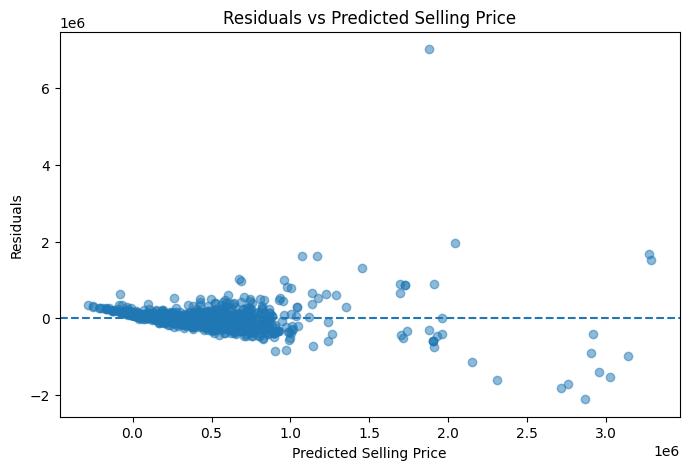

In [330]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Selling Price")

plt.show()

Note: we are looking for a well-behaved linear regression, a fairly random cloud around zero.
A concern would be a clear pattern i.e. line from left to right, suggestinbg potentially that the model is systematically under- or overpredicting at different price levels.
Also if the the spread getting larger as predicted prices increase — a funnel shape. That would indicate non-constant error variance (heteroscedasticity).

OUTPUT: 
Residuals vs Predicted, the dense narrow cloud around zero is what we want. The important part is your observation that as predicted prices become higher, you see a handful of residuals spreading farther away from zero. That suggests the error variance may increase for expensive cars. Given your RMSE is much larger than your MAE, those relatively few large errors are consistent with what the metrics already told us

### 3. Residual distribution

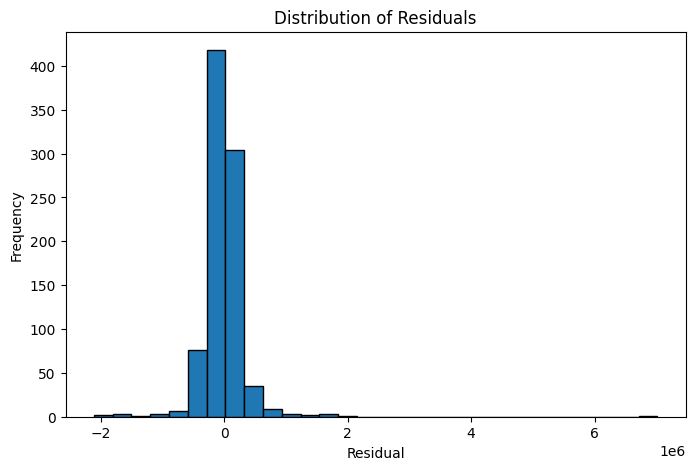

In [335]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

Note: Are errors reasonably centred around zero and roughly symmetric, or strongly skewed?
Earlier EDA and the large difference between MAE = 188,667 and RMSE = 384,020 particular attention to very large residuals must be paid.

**Findings:**

Residuals are concentrated around zero and show an approximately symmetric distribution. However, the residual-versus-predicted plot indicates larger errors among higher-priced vehicles. This is consistent with the substantial difference between MAE and RMSE and suggests that a relatively small number of observations contribute disproportionately to prediction error.

EDA: selling price was strongly right-skewed with extreme high-price observations
→ Model: R² = .517
→ Diagnostics: central residuals look reasonably balanced, but errors increase for some expensive vehicles
→ Metrics: RMSE substantially exceeds MAE.


## Ridge Regression
Ridge should be fitted on scaled numerical predictors, because its penalty depends on coefficient magnitude.

In [336]:
#Create ridge train test
X_train_ridge = X_train_final.copy()
X_test_ridge = X_test_final.copy()

In [337]:
#Scale the nnumeric values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_ridge[["age", "km_driven"]] = scaler.fit_transform(
    X_train_ridge[["age", "km_driven"]]
)

X_test_ridge[["age", "km_driven"]] = scaler.transform(
    X_test_ridge[["age", "km_driven"]]
)

In [338]:
#Verfiy
X_train_ridge[["age", "km_driven"]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,3472.0,6.139482e-17,1.000144,-1.636842,-0.685614,-0.209999,0.503423,5.021760
km_driven,3472.0,-1.125572e-16,1.000144,-1.407571,-0.661301,-0.128237,0.511441,15.791183


The means should now be approximately 0 and standard deviations approximately 1.

In [339]:
#Fit ridge (alpha=1.0 as baseline)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_ridge, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [340]:
#Predict
y_pred_ridge = ridge.predict(X_test_ridge)

In [341]:
#Model evaluation
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

ridge_r2 = r2_score(y_test, y_pred_ridge)

In [348]:
comparison = pd.DataFrame({

    "Model": ["Linear Regression", "Ridge (alpha=1.0)"],
    "MAE": [mae, ridge_mae],
    "RMSE": [rmse, ridge_rmse],
    "R²": [r2, ridge_r2]
})

(

    comparison.style
    .format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "R²": "{:.3f}"
    })
    .hide(axis="index")
)

Model,MAE,RMSE,R²
Linear Regression,"188,667","384,020",0.517
Ridge (alpha=1.0),"188,193","385,118",0.514


* Linear Regression and Ridge provide very similar predictive performance, with Linear showing only a marginal improvement 
Let's test alphas on cross-validation on the training data sets

### Ridge Cross-validation

In [344]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5
)

ridge_cv.fit(X_train_ridge, y_train)

,alphas,"[0.01, 0.1, ...]"
,fit_intercept,True
,scoring,None
,cv,5
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [ ]:
#finding bets performer
ridge_cv.alpha_

np.float64(0.1)

In [346]:
#Final prediction on untouched Test set
y_pred_ridge_cv = ridge_cv.predict(X_test_ridge)

In [347]:
#Model evaluation
ridge_cv_mae = mean_absolute_error(y_test, y_pred_ridge_cv)

ridge_cv_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_cv))

ridge_cv_r2 = r2_score(y_test, y_pred_ridge_cv)

In [ ]:
comparison = pd.DataFrame({

    "Model": ["Linear Regression", "Ridge CV (alpha=0.1)"],
    "MAE": [mae, ridge_cv_mae],
    "RMSE": [rmse, ridge_cv_rmse],
    "R²": [r2, ridge_cv_r2]
})

(
    comparison.style
    .format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "R²": "{:.3f}"
    })
    .hide(axis="index")
)

Model,MAE,RMSE,R²
Linear Regression,"188,667","384,020",0.517
Ridge CV (alpha=0.1),"188,574","384,130",0.516


Findings: 
* Ridge α = 0.1 improves MAE, while RMSE is worse and R² is marginally lower. 
Those differences are tiny relative to selling prices and prediction errors.
* Ridge α = 1 reduces MAE somewhat more, but RMSE deteriorates further and R² falls to .514.

There is no meaningful predictive improvement from Ridge regularisation over ordinary multiple linear regression. The model appears to benefit from only weak regularisation.

Ridge regression produced performance comparable to multiple linear regression. Cross-validation selected a relatively weak regularisation parameter (α = 0.1). The tuned Ridge model achieved a marginally lower MAE, but slightly higher RMSE and lower R² than multiple linear regression. Therefore, regularization did not materially improve predictive performance.

### Models coefficient comparison

In [351]:
# Coeeficients comparison across models

coef_comparison = pd.DataFrame({

    "Feature": X_train_final.columns,
    "Linear": mlr.coef_,
    "Ridge alpha=0.1": ridge_cv.coef_,
    "Ridge alpha=1.0": ridge.coef_

})

In [352]:
#excluding 2 scaled numerical predictors
coef_cat = coef_comparison[
    ~coef_comparison["Feature"].isin(["age", "km_driven"])
].copy()

In [353]:
#Caluylate how much rigde change the coefficients
coef_cat["Change alpha=0.1"] = (
    coef_cat["Ridge alpha=0.1"] - coef_cat["Linear"]
)

coef_cat["Change alpha=1.0"] = (
    coef_cat["Ridge alpha=1.0"] - coef_cat["Linear"]
)

In [354]:
# Sort
coef_cat["Absolute Linear"] = coef_cat["Linear"].abs()

coef_cat = coef_cat.sort_values(
    "Absolute Linear",
    ascending=False

)

In [359]:
#Display Coeffcients
(
    coef_cat
    .style
    .format({
        "Linear": "{:,.0f}",
        "Ridge alpha=0.1": "{:,.0f}",
        "Ridge alpha=1.0": "{:,.0f}",
        "Change alpha=0.1": "{:+,.0f}",
        "Change alpha=1.0": "{:+,.0f}",
        "Absolute Linear": "{:,.0f}"
    })
    .hide(axis="index")
)

Feature,Linear,Ridge alpha=0.1,Ridge alpha=1.0,Change alpha=0.1,Change alpha=1.0,Absolute Linear
brand_Datsun,"-1,198,773","-1,163,380","-934,857","+35,393","+263,917","1,198,773"
brand_Chevrolet,"-1,159,031","-1,127,612","-926,712","+31,419","+232,319","1,159,031"
brand_Fiat,"-1,134,046","-1,098,895","-872,320","+35,151","+261,726","1,134,046"
brand_Tata,"-1,129,278","-1,098,153","-899,407","+31,124","+229,871","1,129,278"
brand_Renault,"-1,122,793","-1,090,966","-887,283","+31,827","+235,510","1,122,793"
brand_BMW,"1,105,457","1,126,656","1,245,402","+21,199","+139,944","1,105,457"
brand_Volkswagen,"-1,069,568","-1,038,949","-843,449","+30,620","+226,119","1,069,568"
brand_Mercedes-Benz,"1,063,599","1,084,950","1,204,991","+21,351","+141,392","1,063,599"
brand_Skoda,"-1,062,452","-1,031,958","-837,167","+30,494","+225,286","1,062,452"
brand_Maruti,"-1,048,606","-1,017,528","-819,266","+31,078","+229,339","1,048,606"


In [358]:
#Check which catgeory was omitted
drop="first"

In [ ]:
for feature, categories in zip(categorical_features, encoder.categories_):
    print(f"{feature}: reference = {categories[0]}")

fuel: reference = CNG
seller_type: reference = Dealer
transmission: reference = Automatic
owner: reference = First Owner
brand: reference = Audi


Interpretation: 
Feature	Linear	Ridge alpha=0.1	Ridge alpha=1.0	Change alpha=0.1	Change alpha=1.0	Absolute Linear
brand_Datsun	-1,198,773	-1,163,380	-934,857	+35,393	+263,917	1,198,773

Holding age, kilometres driven, fuel, seller type, transmission and ownership constant, a Datsun is predicted to sell for approximately 1,198,773 less than an Audi in the Linear Regression model.

And for Ridge α=.1:
The estimated difference is reduced to approximately 1,163,380, demonstrating modest coefficient shrinkage.

**OVERALL RESULTS**

1. Can the models predict unseen data?
Yes. You evaluated both on the same test set using MAE, RMSE and R².

2. Does Ridge improve prediction?
Not materially.

* Linear: MAE 188,667, RMSE 384,020, R² .517
* Ridge α=.1: MAE 188,574, RMSE 384,130, R² .516

3. What did cross-validation tell you?
It selected α=.1, indicating relatively weak regularization.

4. Did Ridge actually regularize the coefficients?
Yes. Your Datsun example shows the mechanism clearly:

−1,198,773 → −1,163,380 at α=.1, with stronger shrinkage at α=1.

5. What did diagnostics tell you?
Residuals were largely centred around zero, but larger errors appeared for higher-priced vehicles. That aligns with your EDA findings and the large MAE–RMSE gap.

**Model comparison:**
Multiple Linear Regression and Ridge Regression produced comparable predictive performance. Five-fold cross-validation selected a relatively weak Ridge penalty (α = 0.1). Although Ridge marginally reduced MAE, Linear Regression achieved slightly lower RMSE and higher R². Ridge also produced modest coefficient shrinkage, but this did not translate into a meaningful improvement in predictive performance. Therefore, the simpler Multiple Linear Regression model was retained as the baseline/preferred model.

### Model improvements / funetuning
test log-transformed selling_price next. 

In [ ]:
# 1. Log-transform the target
y_train_log = np.log1p(y_train)

Do not transform y_test for your final price-based evaluation. We want to evaluate predictions in the original selling-price units.

In [361]:
# 2. Fit a new Linear Regression (same X_train_final)
log_model = LinearRegression()

log_model.fit(X_train_final, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


What has changed: 
* Original model: X → selling_price
* Log model: X → log(selling_price)

In [362]:
# 3. Predict
y_pred_log = log_model.predict(X_test_final)

In [363]:
y_pred_log[:5]

array([12.11032328, 13.08897917, 11.91959109, 13.14033922, 13.7494357 ])

In [364]:
#Convert prediction to prices to actual price units
y_pred_log_price = np.expm1(y_pred_log)

In [365]:
y_pred_log_price[:5]

array([181737.34715142, 483582.44914872, 150179.18561698, 509068.19079133,
       936059.78693533])

In [366]:
# 5. Evaluate on the original price scale
log_mae = mean_absolute_error(y_test, y_pred_log_price)
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log_price))
log_r2 = r2_score(y_test, y_pred_log_price)

In [367]:
log_comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Log-Target Linear Regression"
    ],

    "MAE": [
        mae,
        log_mae
    ],

    "RMSE": [
        rmse,
        log_rmse
    ],

    "R²": [
        r2,
        log_r2
    ]
})

(

    log_comparison.style
    .format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "R²": "{:.3f}"
    })
    .hide(axis="index")

)

Model,MAE,RMSE,R²
Linear Regression,"188,667","384,020",0.517
Log-Target Linear Regression,"143,697","334,489",0.633


Results: 
- MAE decreased from: 188,667 → 143,697 (44,970 less absolute error per prediction on average, roughly a 24% reduction.)
- RMSE decreased: 384,020 → 334,489 (model is also making fewer/severer large prediction errors.)
- R² increased: .517 → .633 (model explain about 63.3% of the variation in test-set selling prices, compared with about 51.7% before.)

This alogns with the EDA anmd next steps:
1. EDA --> selling_price strongly right-skewed + extreme high prices
2. First Baseline regression MAE 188,667 | RMSE 384,020 | R² .517
3. Residual diagnostics -> large errors particularly at higher prices
4. Hypothesis -> target skew may be affecting linear model
5. log(selling_price) -> MAE 143,697 | RMSE 334,489 | R² .633

### Residuals comparison 

In [369]:
#Residuals back on the original price scale:
residuals_log_price = y_test - y_pred_log_price

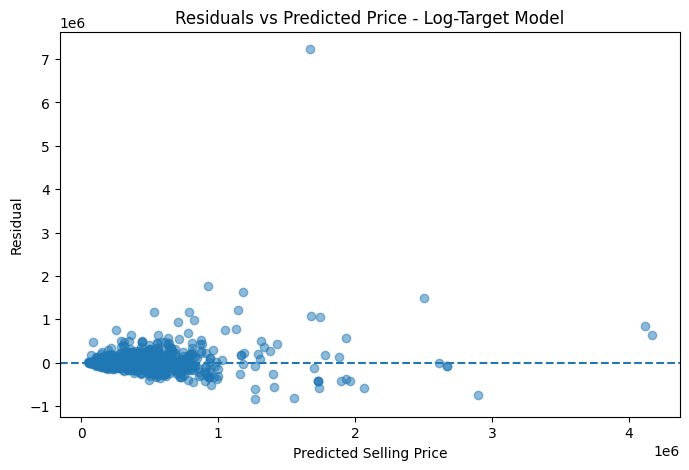

In [370]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_log_price, residuals_log_price, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Price - Log-Target Model")
plt.show()

Following the log transformation of selling price, residuals remained concentrated around zero for the majority of observations, particularly within the main price range. Greater dispersion persisted among higher-priced vehicles, indicating that these observations remain more difficult to predict. Nevertheless, the substantial improvements in MAE, RMSE and R² demonstrate that the log-target specification provides a better overall fit than the untransformed model.

Ridge addressed regularisation → almost no improvement.
Log transformation addressed the skew identified in EDA → substantial improvement, but higher values are harder to predict.

Potential next steps - Ridge on transformed price